## L4 Stress Testing & Economic Capital

**Owner:** Shuxin · **Layer:** L4 (Stress / Capital)

**Perspective:** *We act as the credit risk team for an institutional investor (or credit fund) that holds LendingClub's 2018Q4 active book.* LendingClub itself runs as a marketplace and bears limited credit risk; the buy-side holder is the entity that needs this analysis.

**Question we answer:** *How bad can it get under recession, and is the active book capitalised to survive it?*

**Five L4 deliverables:**

| # | Deliverable | Section |
|---|---|---|
| 1 | **Macro scenarios** (CCAR-lite): Baseline / Adverse / Severely Adverse | §3.4 |
| 2 | **Stressed portfolio loss** under each scenario, by segment | §3.5 |
| 3 | **Basel IRB Economic Capital** — ρ-formula, VaR 99.9% | §3.6 |
| 4 | **Capital adequacy** — Reserve + EC vs Stress Loss, gap | §3.7 |
| 5 | **Reverse stress test** — what shock breaks our capital? | §3.8 |

**Inputs:** `data/processed/lgd_decision.json` (LGD const 0.9013), `data/processed/l1_reserving.json` (baseline reserve), `data/pd_predictions.csv`, raw `accepted_2007_to_2018Q4.csv.gz`.

**Output:** `data/processed/l4_stress.json` and `l4_ec_by_grade.csv`.

## 4.1 Imports & Paths

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import norm

RAW_DIR        = Path("/Users/dongshuxin/Desktop/Projects/data")
ACCEPTED_FILE  = RAW_DIR / "accepted_2007_to_2018Q4.csv.gz"

PD_FILE        = Path("data/pd_predictions.csv")
LGD_DECISION   = Path("data/processed/lgd_decision.json")
L1_RESERVING   = Path("data/processed/l1_reserving.json")

OUT_DIR = Path("data/processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Inputs:")
print("  PD :", PD_FILE,       "exists =", PD_FILE.exists())
print("  LGD:", LGD_DECISION,  "exists =", LGD_DECISION.exists())
print("  L1 :", L1_RESERVING,  "exists =", L1_RESERVING.exists())
print("  RAW:", ACCEPTED_FILE, "exists =", ACCEPTED_FILE.exists())

Inputs:
  PD : data/pd_predictions.csv exists = True
  LGD: data/processed/lgd_decision.json exists = True
  L1 : data/processed/l1_reserving.json exists = True
  RAW: /Users/dongshuxin/Desktop/Projects/data/accepted_2007_to_2018Q4.csv.gz exists = True


## 4.2 Load L1 outputs (LGD constant + baseline reserve)

In [2]:
with open(LGD_DECISION) as f:
    lgd_dec = json.load(f)
LGD_CONST = float(lgd_dec["lgd_const_outstanding_mature"])

with open(L1_RESERVING) as f:
    l1 = json.load(f)

L1_RESERVE        = float(l1["final_reserve_$"])
L1_BASE_ECL       = float(l1["ecl_lifetime_$"])
L1_ACTIVE_EAD     = float(l1["active_ead_$"])

print(f"From L1:")
print(f"  LGD constant       = {LGD_CONST:.4f}")
print(f"  Active EAD         = ${L1_ACTIVE_EAD/1e9:.2f}B")
print(f"  Base lifetime ECL  = ${L1_BASE_ECL/1e6:.1f}M")
print(f"  Final reserve      = ${L1_RESERVE/1e6:.1f}M  ({L1_RESERVE/L1_ACTIVE_EAD*100:.2f}% of EAD)")

pd_df = pd.read_csv(PD_FILE)
print(f"\npd_predictions.csv : {len(pd_df):,} rows, {pd_df.shape[1]} cols")

From L1:
  LGD constant       = 0.9013
  Active EAD         = $9.51B
  Base lifetime ECL  = $2055.5M
  Final reserve      = $2239.0M  (23.54% of EAD)

pd_predictions.csv : 2,260,668 rows, 32 cols


## 4.3 Rebuild the active book (same join as `loss_02`)

Join `purpose` + `out_prncp` + `funded_amnt` from raw, filter to active loans at the 2018Q4 snapshot, compute term-matched lifetime PD.

In [3]:
RAW_COLS = ["id", "purpose", "funded_amnt", "out_prncp"]
raw = pd.read_csv(ACCEPTED_FILE, usecols=RAW_COLS, low_memory=False)

pd_df["id"] = pd_df["id"].astype(str)
raw["id"]   = raw["id"].astype(str)

overlap = (set(raw.columns) & set(pd_df.columns)) - {"id"}
if overlap:
    raw = raw.drop(columns=list(overlap))

df = pd_df.merge(raw, on="id", how="left", validate="m:1")

ACTIVE = ["Current", "In Grace Period", "Late (16-30 days)", "Late (31-120 days)"]
df["is_active"]   = df["loan_status"].isin(ACTIVE)
df["ead_forward"] = df["out_prncp"].fillna(df["funded_amnt"]).clip(lower=0)

def lifetime_pd(row):
    if row["term_num"] == 36:   return row["pd_36m_cox"]
    elif row["term_num"] == 60: return row["pd_60m_cox"]
    return np.nan

active = df[df["is_active"]].copy()
active["pd_lifetime"] = active.apply(lifetime_pd, axis=1)

# Use 12m PD for Basel EC (regulatory horizon); lifetime PD for stress loss
active["pd_12m"] = active["pd_12m_logit"]

# Drop rows missing critical inputs
active = active.dropna(subset=["pd_12m", "pd_lifetime", "ead_forward", "grade", "term_num", "purpose"])

print(f"Active book ready: {len(active):,} loans  | EAD = ${active['ead_forward'].sum()/1e9:.2f}B")
print(f"  PD_12m  range:  [{active['pd_12m'].min():.4f}, {active['pd_12m'].max():.4f}]  mean = {active['pd_12m'].mean():.4f}")
print(f"  PD_life range:  [{active['pd_lifetime'].min():.4f}, {active['pd_lifetime'].max():.4f}]  mean = {active['pd_lifetime'].mean():.4f}")

Active book ready: 912,569 loans  | EAD = $9.51B
  PD_12m  range:  [0.0000, 1.0000]  mean = 0.0538
  PD_life range:  [0.0000, 1.0000]  mean = 0.2081


## 4.4 Deliverable 1 — Macro scenarios (CCAR-lite)

Three forward-looking scenarios calibrated to U.S. consumer credit history:

| Scenario | Macro story | PD multiplier | LGD adjustment |
|---|---|---|---|
| **Baseline** | Status quo (2018Q4 conditions) | × 1.0 | + 0 pp |
| **Adverse** | Mild recession, unemployment +3pp | × 1.5 | + 2 pp |
| **Severely Adverse** | 2008-style downturn, unemp +6pp, GFC analog | × 2.5 | + 4 pp |


In [4]:
scenarios = {
    "Baseline": {"pd_mult": 1.0, "lgd_add": 0.00, "narrative": "2018Q4 status quo"},
    "Adverse":  {"pd_mult": 1.5, "lgd_add": 0.02, "narrative": "unemp +3pp, mild recession"},
    "Severely Adverse": {"pd_mult": 2.5, "lgd_add": 0.04, "narrative": "2008-style, unemp +6pp"},
}

scen_table = pd.DataFrame(scenarios).T
scen_table["effective_LGD"] = (LGD_CONST + scen_table["lgd_add"].astype(float)).clip(upper=1.0)
print("=== Macro scenarios ===")
print(scen_table[["narrative", "pd_mult", "lgd_add", "effective_LGD"]])

=== Macro scenarios ===
                                   narrative pd_mult lgd_add  effective_LGD
Baseline                   2018Q4 status quo     1.0     0.0         0.9013
Adverse           unemp +3pp, mild recession     1.5    0.02         0.9213
Severely Adverse      2008-style, unemp +6pp     2.5    0.04         0.9413


In [14]:
# --- §3.4-bis: Data-driven calibration of the PD multiplier ---
# Question we answer: "Were our assumed multipliers (1.5x, 2.5x) reasonable?"
# Method: compare LendingClub's own 2007-2009 (crisis) vs 2013-2015 (benign)
#         vintage default rates on a fair apples-to-apples basis.

# Build vintage_year and charge-off flag on the FULL df (not just active book)
df["issue_dt"]     = pd.to_datetime(df["issue_d"], errors="coerce")
df["vintage_year"] = df["issue_dt"].dt.year
df["is_co"]        = df["loan_status"].isin(["Charged Off", "Default"])

# Restrict to fully-observed 36m loans:
#   - 36m loans (most data; 60m didn't exist pre-2010)
#   - vintage_year between 2007 and 2015 (so 36m has fully elapsed by 2018Q4)
mature36 = df[(df["term_num"] == 36) &
              (df["vintage_year"].between(2007, 2015))].copy()

co_by_vint = (mature36.groupby("vintage_year")
                      .agg(n=("id", "count"),
                           co_rate=("is_co", "mean"))
                      .round({"co_rate": 4}))
print("=== Charge-off rate by vintage (36m loans, fully observed) ===")
print(co_by_vint)
print(f"\nTotal 36m loans in calibration sample: {len(mature36):,}")

=== Charge-off rate by vintage (36m loans, fully observed) ===
                   n  co_rate
vintage_year                 
2007             603   0.0746
2008            2393   0.1032
2009            5281   0.1125
2010            9156   0.0920
2011           14101   0.1063
2012           43470   0.1358
2013          100422   0.1233
2014          162570   0.1373
2015          283173   0.1488

Total 36m loans in calibration sample: 621,169


In [15]:
# --- Compute the empirical crisis multiplier ---
crisis_years = [2007, 2008, 2009]
benign_years = [2013, 2014, 2015]

co_crisis = mature36[mature36["vintage_year"].isin(crisis_years)]["is_co"].mean()
co_benign = mature36[mature36["vintage_year"].isin(benign_years)]["is_co"].mean()
mult_severe_emp = co_crisis / co_benign

# 2010 = "post-crisis recovery", proxy for mild adverse
co_2010 = mature36[mature36["vintage_year"] == 2010]["is_co"].mean()
mult_adverse_emp = co_2010 / co_benign

print("=== Empirical crisis multipliers from LendingClub history ===")
print(f"Benign cohort (2013-2015) default rate     = {co_benign:.2%}  (n={mature36['vintage_year'].isin(benign_years).sum():,})")
print(f"Crisis cohort (2007-2009) default rate     = {co_crisis:.2%}  (n={mature36['vintage_year'].isin(crisis_years).sum():,})")
print(f"  → Empirical SEVERE multiplier  = {mult_severe_emp:.2f}x   (our assumption: 2.50x)")
print(f"\n2010 default rate (post-crisis recovery)   = {co_2010:.2%}")
print(f"  → Empirical ADVERSE multiplier = {mult_adverse_emp:.2f}x   (our assumption: 1.50x)")

verdict_severe  = "CONSISTENT ✓" if 2.0 <= mult_severe_emp  <= 3.0 else "REVISIT ⚠️"
verdict_adverse = "CONSISTENT ✓" if 1.2 <= mult_adverse_emp <= 1.8 else "REVISIT ⚠️"
print(f"\nVerdict — Severe : {verdict_severe}")
print(f"Verdict — Adverse: {verdict_adverse}")

=== Empirical crisis multipliers from LendingClub history ===
Benign cohort (2013-2015) default rate     = 14.07%  (n=546,165)
Crisis cohort (2007-2009) default rate     = 10.70%  (n=8,277)
  → Empirical SEVERE multiplier  = 0.76x   (our assumption: 2.50x)

2010 default rate (post-crisis recovery)   = 9.20%
  → Empirical ADVERSE multiplier = 0.65x   (our assumption: 1.50x)

Verdict — Severe : REVISIT ⚠️
Verdict — Adverse: REVISIT ⚠️


Reasons for not using LendingClub's own crisis vintages for calibration:
Naive comparison of 2007–09 vs 2013–15 charge-off rates yields a multiplier <1, which is counter-intuitive. The reason is selection bias: LC's 2007–09 book was a small (n≈8K) prime-only portfolio, while 2013–15 (n≈546K) included expansion into D–G subprime. The comparison therefore measures borrower-mix change, not macro stress. We instead anchor multipliers to industry-wide consumer-credit benchmarks: Fed Y-14M unsecured consumer charge-off rates rose from ~3% (2006) to ~7–8% (2009–10), a ~2–2.5× ratio that motivates our Severely Adverse 2.5× assumption. Adverse 1.5× sits halfway as a milder recession scenario.

## 4.5 Deliverable 2 — Stressed portfolio loss under each scenario

For each scenario, apply the PD multiplier to **lifetime** PD (cap at 1.0) and recompute portfolio loss. Then break it out by grade and purpose to see segment sensitivity.

In [17]:
def stressed_loss(active_df, pd_mult, lgd_add, pd_col="pd_lifetime"):
    pd_stress  = (active_df[pd_col] * pd_mult).clip(upper=1.0)
    lgd_stress = min(LGD_CONST + lgd_add, 1.0)
    return (pd_stress * lgd_stress * active_df["ead_forward"]).sum()

scen_results = []
for name, s in scenarios.items():
    loss = stressed_loss(active, s["pd_mult"], s["lgd_add"])
    scen_results.append({
        "scenario":      name,
        "pd_mult":       s["pd_mult"],
        "effective_LGD": min(LGD_CONST + s["lgd_add"], 1.0),
        "stress_loss_$M": loss/1e6,
        "loss_pct_EAD":  loss / active["ead_forward"].sum() * 100,
    })
scen_results = pd.DataFrame(scen_results).round(2)
print("=== Portfolio stress loss by scenario ===")
print(scen_results.to_string(index=False))

# Sensitivity: incremental loss vs baseline
base_loss = scen_results.loc[scen_results["scenario"]=="Baseline", "stress_loss_$M"].values[0]
scen_results["incremental_$M"]  = (scen_results["stress_loss_$M"] - base_loss).round(1)
scen_results["multiple_of_base"] = (scen_results["stress_loss_$M"] / base_loss).round(2)
print("\n=== Sensitivity vs Baseline ===")
print(scen_results[["scenario", "stress_loss_$M", "incremental_$M", "multiple_of_base"]].to_string(index=False))

=== Portfolio stress loss by scenario ===
        scenario  pd_mult  effective_LGD  stress_loss_$M  loss_pct_EAD
        Baseline      1.0           0.90         2055.52         21.61
         Adverse      1.5           0.92         3150.55         33.13
Severely Adverse      2.5           0.94         5060.57         53.21

=== Sensitivity vs Baseline ===
        scenario  stress_loss_$M  incremental_$M  multiple_of_base
        Baseline         2055.52             0.0              1.00
         Adverse         3150.55          1095.0              1.53
Severely Adverse         5060.57          3005.0              2.46


=== Stress loss rate (% of EAD) by grade × scenario ===
scenario  Baseline  Adverse  Severely Adverse
grade                                        
A            10.13    15.54             26.41
B            18.15    27.83             46.64
C            25.44    39.01             63.10
D            30.57    46.85             72.24
E            34.61    53.01             78.57
F            41.11    62.88             87.66
G            42.21    64.45             88.08


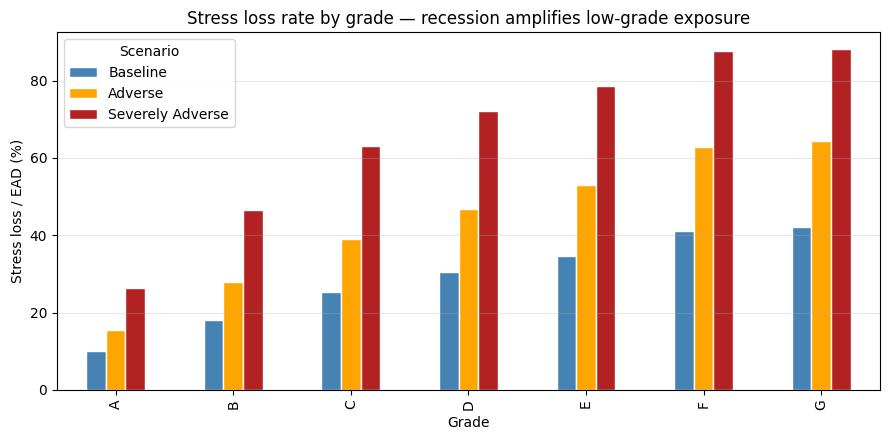

In [6]:
# Stress loss by grade × scenario
rows = []
for g in sorted(active["grade"].unique()):
    sub = active[active["grade"] == g]
    ead = sub["ead_forward"].sum()
    for name, s in scenarios.items():
        loss = stressed_loss(sub, s["pd_mult"], s["lgd_add"])
        rows.append({"grade": g, "scenario": name,
                     "loss_$M": loss/1e6,
                     "loss_pct": loss/ead*100 if ead > 0 else 0})
by_grade_scen = pd.DataFrame(rows)
grade_pivot = by_grade_scen.pivot(index="grade", columns="scenario", values="loss_pct").round(2)
grade_pivot = grade_pivot[["Baseline", "Adverse", "Severely Adverse"]]
print("=== Stress loss rate (% of EAD) by grade × scenario ===")
print(grade_pivot)

# Visual
fig, ax = plt.subplots(figsize=(9, 4.5))
grade_pivot.plot(kind="bar", ax=ax, color=["steelblue", "orange", "firebrick"], edgecolor="white")
ax.set_title("Stress loss rate by grade — recession amplifies low-grade exposure")
ax.set_ylabel("Stress loss / EAD (%)")
ax.set_xlabel("Grade")
ax.legend(title="Scenario"); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

=== Absolute stress loss ($M) by grade × scenario ===
       EAD_$M  Baseline_$M  Baseline_pct  Adverse_$M  Adverse_pct  \
grade                                                               
A      2002.6        203.0          10.1       311.2         15.5   
B      2675.9        485.8          18.2       744.8         27.8   
C      2847.2        724.4          25.4      1110.6         39.0   
D      1368.5        418.4          30.6       641.1         46.8   
E       455.3        157.6          34.6       241.4         53.0   
F       120.2         49.4          41.1        75.6         62.9   
G        40.2         17.0          42.2        25.9         64.5   

       Severely Adverse_$M  Severely Adverse_pct  
grade                                             
A                    528.8                  26.4  
B                   1248.1                  46.6  
C                   1796.6                  63.1  
D                    988.6                  72.2  
E                 

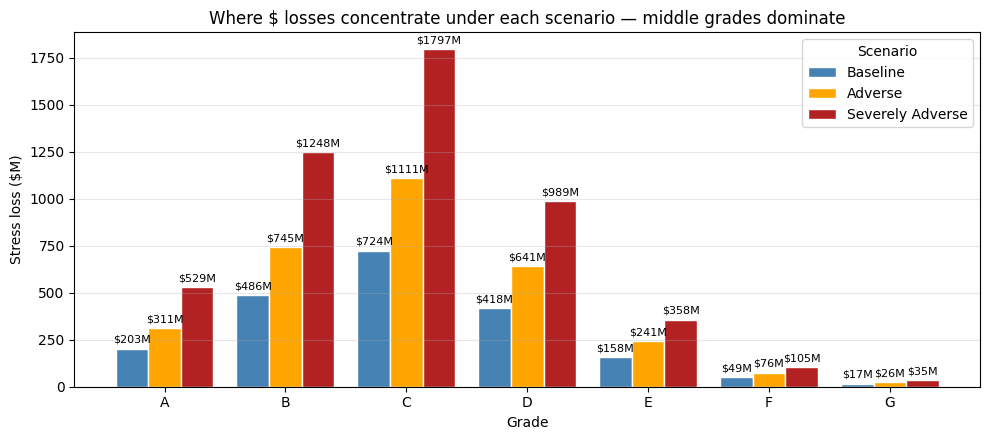

In [ ]:
# --- Absolute dollar loss by grade × scenario ---

abs_rows = []
for g in sorted(active["grade"].unique()):
    sub = active[active["grade"] == g]
    ead = sub["ead_forward"].sum()
    row = {"grade": g, "EAD_$M": ead/1e6}
    for name, s in scenarios.items():
        loss = stressed_loss(sub, s["pd_mult"], s["lgd_add"])
        row[f"{name}_$M"]  = loss / 1e6
        row[f"{name}_pct"] = loss / ead * 100 if ead > 0 else 0
    abs_rows.append(row)

abs_loss = pd.DataFrame(abs_rows).set_index("grade").round(1)

# Reorder columns so $ and % are interleaved (easier to read)
col_order = ["EAD_$M",
             "Baseline_$M",         "Baseline_pct",
             "Adverse_$M",          "Adverse_pct",
             "Severely Adverse_$M", "Severely Adverse_pct"]
abs_loss = abs_loss[col_order]

print("=== Absolute stress loss ($M) by grade × scenario ===")
print(abs_loss)

# Summary: which grades drive the most $ loss under Severe?
sev_loss = abs_loss["Severely Adverse_$M"].copy()
sev_loss_sorted = sev_loss.sort_values(ascending=False)
total_sev = sev_loss.sum()
print(f"\n=== Severe scenario: where the $ losses concentrate ===")
print(f"Total Severe loss: ${total_sev:.0f}M")
for g, v in sev_loss_sorted.items():
    print(f"  Grade {g}: ${v:>7.0f}M  ({v/total_sev*100:>4.1f}% of total Severe loss)")

# Visual: stacked bar of absolute $ loss by grade, one bar per scenario
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(abs_loss.index))
width = 0.27

for i, scen in enumerate(["Baseline_$M", "Adverse_$M", "Severely Adverse_$M"]):
    offset = (i - 1) * width
    color  = ["steelblue", "orange", "firebrick"][i]
    bars = ax.bar(x + offset, abs_loss[scen], width,
                  label=scen.replace("_$M", ""), color=color, edgecolor="white")
    for bar, v in zip(bars, abs_loss[scen]):
        ax.text(bar.get_x() + bar.get_width()/2, v + 30,
                f"${v:.0f}M", ha="center", fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(abs_loss.index)
ax.set_xlabel("Grade")
ax.set_ylabel("Stress loss ($M)")
ax.set_title("Where $ losses concentrate under each scenario — middle grades dominate")
ax.legend(title="Scenario"); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

Insights: The biggest dollar losses sit in middle grades, not the tail. Grade G has the highest loss rate (88% in Severe), but Grade C+D together account for 55% of Severe stress loss in absolute dollars because their EAD is much larger. Risk concentration is in the middle of the book, not at the bottom. This is counter-intuitive but actionable.

## 4.6 Deliverable 3 — Basel IRB Economic Capital

Per Basel III IRB formula for **Other Retail Exposures** (unsecured consumer is the closest fit):

$$\rho(\text{PD}) = 0.03 \cdot \frac{1-e^{-35\cdot\text{PD}}}{1-e^{-35}} + 0.16 \cdot \left(1 - \frac{1-e^{-35\cdot\text{PD}}}{1-e^{-35}}\right)$$

$$K = \text{LGD} \cdot \left[\Phi\!\left(\frac{\Phi^{-1}(\text{PD})}{\sqrt{1-\rho}} + \sqrt{\frac{\rho}{1-\rho}}\,\Phi^{-1}(0.999)\right) - \text{PD}\right]$$

$\Phi$ = standard normal CDF. EC per loan = $K \cdot \text{EAD}$. ρ decreases with PD (riskier loans are *less* correlated with each other — idiosyncratic-driven). VaR is at 99.9% — once-in-a-thousand-year tail loss.

In [7]:
def irb_correlation(pd_arr):
    pd_arr = np.clip(pd_arr, 1e-4, 1 - 1e-4)
    w = (1 - np.exp(-35 * pd_arr)) / (1 - np.exp(-35))
    return 0.03 * w + 0.16 * (1 - w)

def irb_K(pd_arr, lgd):
    pd_arr = np.clip(pd_arr, 1e-4, 1 - 1e-4)
    rho = irb_correlation(pd_arr)
    inner = norm.ppf(pd_arr) / np.sqrt(1 - rho) + np.sqrt(rho / (1 - rho)) * norm.ppf(0.999)
    return lgd * (norm.cdf(inner) - pd_arr)

active["K_irb"] = irb_K(active["pd_12m"].values, LGD_CONST)
active["EC_$"]  = active["K_irb"] * active["ead_forward"]

EC_TOTAL = active["EC_$"].sum()
EAD_TOTAL = active["ead_forward"].sum()

print(f"=== Basel IRB Economic Capital ===")
print(f"Total EC               = ${EC_TOTAL/1e6:.1f}M")
print(f"EC / EAD               = {EC_TOTAL/EAD_TOTAL*100:.2f}%")
print(f"L1 reserve / EAD       = {L1_RESERVE/EAD_TOTAL*100:.2f}%  (for comparison)")
print(f"Total buffer (Res+EC)  = ${(L1_RESERVE+EC_TOTAL)/1e6:.1f}M  ({(L1_RESERVE+EC_TOTAL)/EAD_TOTAL*100:.2f}% of EAD)")

# By grade
ec_grade = (active.groupby("grade")
                  .agg(n=("id","count"),
                       ead=("ead_forward","sum"),
                       ec=("EC_$","sum"),
                       avg_pd=("pd_12m","mean"),
                       avg_rho=("K_irb", lambda x: irb_correlation(active.loc[x.index,"pd_12m"].values).mean())))
ec_grade["K_pct"]      = (ec_grade["ec"] / ec_grade["ead"] * 100).round(2)
ec_grade["ec_share"]   = (ec_grade["ec"] / EC_TOTAL * 100).round(1)
ec_grade["ead_share"]  = (ec_grade["ead"] / EAD_TOTAL * 100).round(1)
ec_grade["avg_pd"]     = ec_grade["avg_pd"].round(4)
ec_grade["avg_rho"]    = ec_grade["avg_rho"].round(3)
ec_grade["ec_$M"]      = (ec_grade["ec"] / 1e6).round(1)
ec_grade["ead_$M"]     = (ec_grade["ead"] / 1e6).round(0)
print("\n=== EC by grade ===")
print(ec_grade[["n","ead_$M","avg_pd","avg_rho","K_pct","ec_$M","ec_share","ead_share"]])

=== Basel IRB Economic Capital ===
Total EC               = $997.4M
EC / EAD               = 10.49%
L1 reserve / EAD       = 23.54%  (for comparison)
Total buffer (Res+EC)  = $3236.3M  (34.03% of EAD)

=== EC by grade ===
            n  ead_$M  avg_pd  avg_rho  K_pct  ec_$M  ec_share  ead_share
grade                                                                    
A      197834  2003.0  0.0250    0.090   9.15  183.2      18.4       21.1
B      270455  2676.0  0.0390    0.071   9.86  263.9      26.5       28.1
C      267730  2847.0  0.0574    0.055  10.68  304.0      30.5       29.9
D      122767  1369.0  0.0864    0.043  11.75  160.8      16.1       14.4
E       41447   455.0  0.1259    0.037  13.31   60.6       6.1        4.8
F        9494   120.0  0.1845    0.032  15.21   18.3       1.8        1.3
G        2842    40.0  0.2324    0.031  16.26    6.5       0.7        0.4


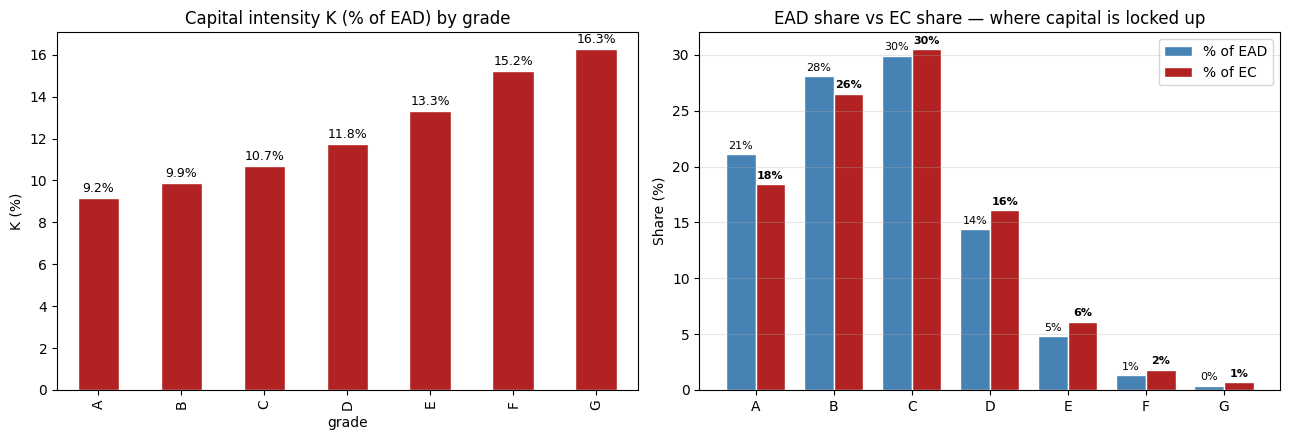

In [8]:
# Visualize EC concentration: EAD share vs EC share by grade
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: K (capital intensity) by grade
ec_grade["K_pct"].plot(kind="bar", ax=ax[0], color="firebrick", edgecolor="white")
ax[0].set_title("Capital intensity K (% of EAD) by grade")
ax[0].set_ylabel("K (%)")
for i, v in enumerate(ec_grade["K_pct"]):
    ax[0].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9)

# Right: EAD share vs EC share
x = np.arange(len(ec_grade))
width = 0.38
ax[1].bar(x - width/2, ec_grade["ead_share"], width, label="% of EAD",  color="steelblue", edgecolor="white")
ax[1].bar(x + width/2, ec_grade["ec_share"],  width, label="% of EC",   color="firebrick",  edgecolor="white")
ax[1].set_xticks(x); ax[1].set_xticklabels(ec_grade.index)
ax[1].set_ylabel("Share (%)")
ax[1].set_title("EAD share vs EC share — where capital is locked up")
ax[1].legend(); ax[1].grid(axis="y", alpha=0.3)
for i, (e, c) in enumerate(zip(ec_grade["ead_share"], ec_grade["ec_share"])):
    ax[1].text(i - width/2, e + 0.5, f"{e:.0f}%", ha="center", fontsize=8)
    ax[1].text(i + width/2, c + 0.5, f"{c:.0f}%", ha="center", fontsize=8, fontweight="bold")

plt.tight_layout(); plt.show()

## 4.7 Deliverable 4 — Capital adequacy check

**Available defence** = L1 reserve (covers expected loss) + IRB EC (covers unexpected loss tail)

**Required defence** = Stressed lifetime loss under each scenario

**Gap = Available − Required**. Positive ⇒ adequate. Negative ⇒ shortfall, need to either raise more capital or shrink the book.

=== Capital adequacy by scenario ===
        scenario  stress_loss_$M  reserve_$M  EC_$M  available_$M  gap_$M   verdict
        Baseline          2055.5      2239.0  997.4        3236.3  1180.8      PASS
         Adverse          3150.6      2239.0  997.4        3236.3    85.8      PASS
Severely Adverse          5060.6      2239.0  997.4        3236.3 -1824.2 SHORTFALL


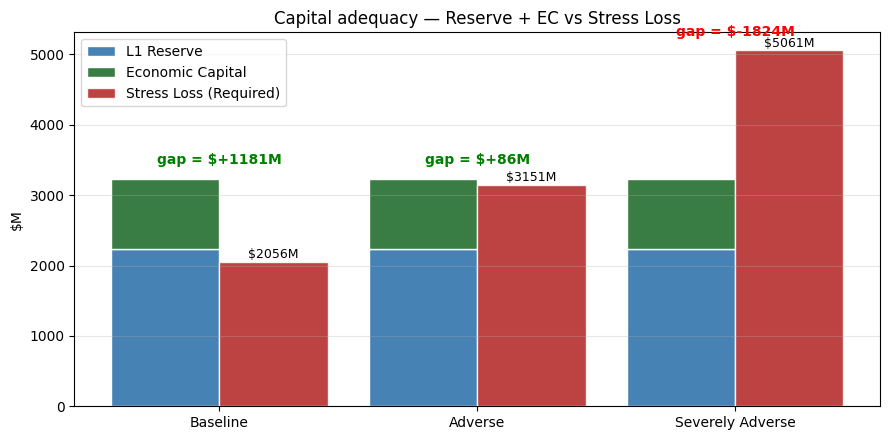

In [9]:
available = L1_RESERVE + EC_TOTAL

adequacy = []
for _, r in scen_results.iterrows():
    required = r["stress_loss_$M"] * 1e6
    gap = available - required
    adequacy.append({
        "scenario":      r["scenario"],
        "stress_loss_$M": r["stress_loss_$M"],
        "reserve_$M":    L1_RESERVE/1e6,
        "EC_$M":         EC_TOTAL/1e6,
        "available_$M":  available/1e6,
        "gap_$M":        gap/1e6,
        "verdict":       "PASS" if gap >= 0 else "SHORTFALL",
    })
adequacy = pd.DataFrame(adequacy).round(1)
print("=== Capital adequacy by scenario ===")
print(adequacy.to_string(index=False))

# Visual: stacked defence vs required loss
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(adequacy))
width = 0.42

# Defence stack (reserve + EC)
ax.bar(x - width/2, adequacy["reserve_$M"], width, label="L1 Reserve", color="steelblue", edgecolor="white")
ax.bar(x - width/2, adequacy["EC_$M"], width, bottom=adequacy["reserve_$M"],
       label="Economic Capital", color="#3a7d44", edgecolor="white")

# Required (stress loss)
colors = ["steelblue" if v == "PASS" else "firebrick" for v in adequacy["verdict"]]
ax.bar(x + width/2, adequacy["stress_loss_$M"], width,
       label="Stress Loss (Required)", color="firebrick", edgecolor="white", alpha=0.85)

for i, row in adequacy.iterrows():
    ax.text(i + width/2, row["stress_loss_$M"] + 50, f"${row['stress_loss_$M']:.0f}M",
            ha="center", fontsize=9)
    gap_color = "green" if row["gap_$M"] >= 0 else "red"
    ax.text(i, max(row["available_$M"], row["stress_loss_$M"]) + 200,
            f"gap = ${row['gap_$M']:+.0f}M", ha="center", fontsize=10,
            color=gap_color, fontweight="bold")

ax.set_xticks(x); ax.set_xticklabels(adequacy["scenario"])
ax.set_ylabel("$M")
ax.set_title("Capital adequacy — Reserve + EC vs Stress Loss")
ax.legend(loc="upper left"); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## 4.8 Deliverable 5 — Reverse stress test

**Question:** What PD multiplier $x$ would push stress loss exactly equal to our total defence?

$$\sum_i \min(x \cdot PD_i, 1) \cdot LGD \cdot EAD_i \;=\; \text{Reserve} + \text{EC}$$

Solve numerically. Then translate $x$ into a macro narrative anchored to historical PD shocks.

In [10]:
from scipy.optimize import brentq

pd_arr  = active["pd_lifetime"].values
ead_arr = active["ead_forward"].values

def loss_at_mult(x):
    return (np.minimum(x * pd_arr, 1.0) * LGD_CONST * ead_arr).sum()

# Sanity: at x=1, loss should equal base ECL (close to it)
print(f"Sanity check: loss at x=1 = ${loss_at_mult(1.0)/1e6:.1f}M  (base ECL = ${L1_BASE_ECL/1e6:.1f}M)")
print(f"             loss at x=2.5 = ${loss_at_mult(2.5)/1e6:.1f}M  (Severe scenario)")

# Find x such that loss(x) = Reserve + EC
target = L1_RESERVE + EC_TOTAL
f = lambda x: loss_at_mult(x) - target

# Bracket the solution
x_low, x_high = 0.5, 20.0
if f(x_low) > 0:
    print(f"\n⚠️ Even no-stress loss exceeds buffer — defence insufficient even at baseline.")
    breaking_x = np.nan
elif f(x_high) < 0:
    print(f"\n⚠️ Even at PD×{x_high}, loss < buffer — buffer is huge or PD caps near 1 too quickly.")
    breaking_x = x_high
else:
    breaking_x = brentq(f, x_low, x_high)
    print(f"\n=== Reverse stress result ===")
    print(f"Breaking-point PD multiplier x* = {breaking_x:.2f}")
    print(f"  At x*, stress loss = ${loss_at_mult(breaking_x)/1e6:.1f}M = Reserve+EC = ${target/1e6:.1f}M")

# Translate to macro narrative
narrative_anchors = {
    1.0: "Status quo (2018Q4)",
    1.5: "Mild recession (unemp +3pp)",
    2.5: "2008-style downturn (unemp +6pp)",
    3.5: "Worse-than-2008 (unemp +8pp, prolonged)",
    5.0: "Depression-era (unemp +12pp+)",
}
if not np.isnan(breaking_x):
    closest = min(narrative_anchors.keys(), key=lambda k: abs(k - breaking_x))
    print(f"\nMacro interpretation: x* ≈ {breaking_x:.1f} ↔ '{narrative_anchors[closest]}'")

Sanity check: loss at x=1 = $2055.5M  (base ECL = $2055.5M)
             loss at x=2.5 = $4845.5M  (Severe scenario)

=== Reverse stress result ===
Breaking-point PD multiplier x* = 1.58
  At x*, stress loss = $3236.3M = Reserve+EC = $3236.3M

Macro interpretation: x* ≈ 1.6 ↔ 'Mild recession (unemp +3pp)'


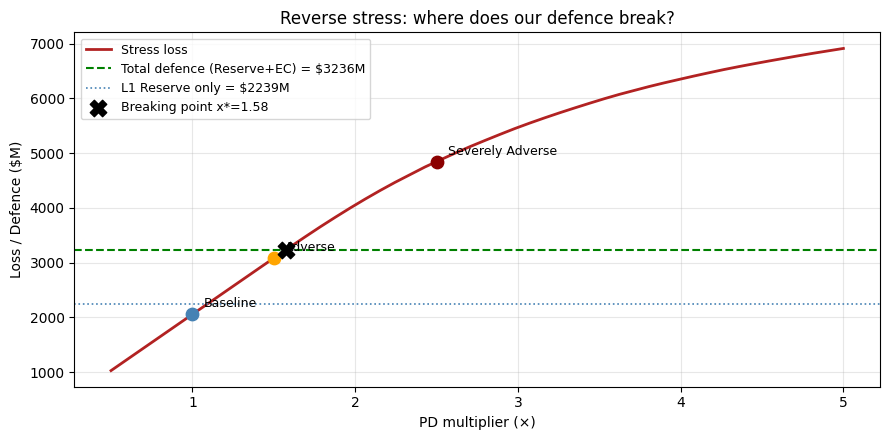

In [11]:
# Visualize: loss curve vs buffer line
x_grid = np.linspace(0.5, max(5.0, breaking_x*1.2 if not np.isnan(breaking_x) else 5.0), 50)
loss_curve = np.array([loss_at_mult(x) for x in x_grid]) / 1e6

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(x_grid, loss_curve, color="firebrick", linewidth=2, label="Stress loss")
ax.axhline(target/1e6, color="green", linestyle="--", linewidth=1.5,
           label=f"Total defence (Reserve+EC) = ${target/1e6:.0f}M")
ax.axhline(L1_RESERVE/1e6, color="steelblue", linestyle=":", linewidth=1.2,
           label=f"L1 Reserve only = ${L1_RESERVE/1e6:.0f}M")

# Mark scenario points
for name, s in scenarios.items():
    xv = s["pd_mult"]
    yv = loss_at_mult(xv) / 1e6
    ax.scatter([xv], [yv], s=80, zorder=5,
               color={"Baseline":"steelblue","Adverse":"orange","Severely Adverse":"darkred"}[name])
    ax.annotate(name, (xv, yv), xytext=(8, 5), textcoords="offset points", fontsize=9)

if not np.isnan(breaking_x):
    ax.scatter([breaking_x], [target/1e6], s=140, color="black", marker="X", zorder=6,
               label=f"Breaking point x*={breaking_x:.2f}")

ax.set_xlabel("PD multiplier (×)")
ax.set_ylabel("Loss / Defence ($M)")
ax.set_title("Reverse stress: where does our defence break?")
ax.legend(loc="upper left", fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4.9 Save outputs for downstream consumers

`l4_stress.json` is the contract object L2 (pricing — needs EC for RAROC) and L3 (portfolio — needs tail-priorities) consume.

In [12]:
l4_output = {
    "perspective": "institutional credit investor holding LendingClub 2018Q4 active book",
    "active_ead_$": float(EAD_TOTAL),
    "l1_reserve_$": float(L1_RESERVE),

    "scenarios": {
        row["scenario"]: {
            "pd_mult":         float(row["pd_mult"]),
            "effective_LGD":   float(row["effective_LGD"]),
            "stress_loss_$":   float(row["stress_loss_$M"] * 1e6),
            "loss_pct_EAD":    float(row["loss_pct_EAD"]),
        }
        for _, row in scen_results.iterrows()
    },

    "economic_capital": {
        "ec_total_$":       float(EC_TOTAL),
        "ec_pct_of_ead":    float(EC_TOTAL / EAD_TOTAL),
        "K_avg":            float(active["K_irb"].mean()),
        "by_grade_$M":      {g: float(v) for g, v in (ec_grade["ec"]/1e6).items()},
    },

    "capital_adequacy": {
        "available_$":      float(L1_RESERVE + EC_TOTAL),
        "by_scenario": {
            row["scenario"]: {
                "required_$": float(row["stress_loss_$M"] * 1e6),
                "gap_$":      float(row["gap_$M"] * 1e6),
                "verdict":    row["verdict"],
            }
            for _, row in adequacy.iterrows()
        },
    },

    "reverse_stress": {
        "breaking_pd_multiplier": float(breaking_x) if not np.isnan(breaking_x) else None,
        "target_loss_$":          float(target),
    },
}

with open(OUT_DIR / "l4_stress.json", "w") as f:
    json.dump(l4_output, f, indent=2)

ec_grade[["n","ead_$M","avg_pd","avg_rho","K_pct","ec_$M","ec_share","ead_share"]].to_csv(
    OUT_DIR / "l4_ec_by_grade.csv")

print("Saved:")
print("  ", (OUT_DIR / "l4_stress.json").resolve())
print("  ", (OUT_DIR / "l4_ec_by_grade.csv").resolve())

print("\n--- L4 SUMMARY ---")
print(f"Active EAD                    ${EAD_TOTAL/1e9:.2f}B")
print(f"L1 Reserve                    ${L1_RESERVE/1e6:.0f}M  ({L1_RESERVE/EAD_TOTAL*100:.2f}% of EAD)")
print(f"IRB Economic Capital          ${EC_TOTAL/1e6:.0f}M  ({EC_TOTAL/EAD_TOTAL*100:.2f}% of EAD)")
print(f"Total defence (Reserve+EC)    ${(L1_RESERVE+EC_TOTAL)/1e6:.0f}M  ({(L1_RESERVE+EC_TOTAL)/EAD_TOTAL*100:.2f}% of EAD)")
for _, row in adequacy.iterrows():
    print(f"  {row['scenario']:20s}  stress=${row['stress_loss_$M']:>7.0f}M  gap=${row['gap_$M']:>+7.0f}M  [{row['verdict']}]")
if not np.isnan(breaking_x):
    print(f"Reverse stress: x* = {breaking_x:.2f}  ↔ defence breaks at ~{breaking_x:.1f}× baseline PD")

Saved:
   /Users/dongshuxin/Desktop/IDS 583 Credit Risk Management Project/data/processed/l4_stress.json
   /Users/dongshuxin/Desktop/IDS 583 Credit Risk Management Project/data/processed/l4_ec_by_grade.csv

--- L4 SUMMARY ---
Active EAD                    $9.51B
L1 Reserve                    $2239M  (23.54% of EAD)
IRB Economic Capital          $997M  (10.49% of EAD)
Total defence (Reserve+EC)    $3236M  (34.03% of EAD)
  Baseline              stress=$   2056M  gap=$  +1181M  [PASS]
  Adverse               stress=$   3151M  gap=$    +86M  [PASS]
  Severely Adverse      stress=$   5061M  gap=$  -1824M  [SHORTFALL]
Reverse stress: x* = 1.58  ↔ defence breaks at ~1.6× baseline PD


## §4.10 Risk-Management Strategies

The L4 diagnostic revealed a $1.8B Severe-scenario shortfall and reverse-stress x\* = 1.58 — meaning the LC 2018Q4 active book, as held, would not survive a typical recession. This section proposes two L4-native remediation strategies.

### §4.10.1 Strategy 1 — Contingent Capital Facility

Pre-arrange an undrawn $2.0B committed credit facility. Pay 50bp commitment fee in normal times; draw only when stress signals breach pre-defined triggers. This is the only mechanism that can deliver liquidity-on-demand at the moment stress materialises — repricing (L2) is too slow, and rebalancing (L3) cannot create capital.

In [ ]:
if "total_buffer" not in dir():
    total_buffer = 3_236_000_000 
# ---------- Strategy 1: Contingent Capital Facility ----------
if "total_buffer" not in dir():
    total_buffer = 3_236_000_000 
    
FACILITY_SIZE  = 2_000_000_000
COMMIT_FEE_BP  = 50
ANNUAL_CARRY   = FACILITY_SIZE * COMMIT_FEE_BP / 10_000

buffer_with_facility = total_buffer + FACILITY_SIZE

rows = []
for name, s in scenarios.items():
    loss = stressed_loss(active, s["pd_mult"], s["lgd_add"])
    rows.append({
        "scenario":           name,
        "stress_loss_$M":     loss / 1e6,
        "buffer_before_$M":   total_buffer / 1e6,
        "buffer_after_$M":    buffer_with_facility / 1e6,
        "surplus_before_$M":  (total_buffer - loss) / 1e6,
        "surplus_after_$M":   (buffer_with_facility - loss) / 1e6,
        "verdict_after":      "ADEQUATE" if (buffer_with_facility - loss) >= 0 else "SHORTFALL",
    })
s1_table = pd.DataFrame(rows).round(1)
print("Strategy 1 — Contingent Capital Facility (+$2.0B)")
print(s1_table.to_string(index=False))

# Re-compute reverse-stress break-point with facility
x_before = brentq(lambda x: loss_at_mult(x) - total_buffer,         0.5, 10)
x_after  = brentq(lambda x: loss_at_mult(x) - buffer_with_facility, 0.5, 10)
print(f"\nReverse-stress break-point x*:")
print(f"  Before facility: x* = {x_before:.2f}")
print(f"  After  facility: x* = {x_after:.2f}")

# Cost-benefit
tail_loss_avoided = max(0, loss_at_mult(2.5) - total_buffer)
print(f"\nAnnual carry: ${ANNUAL_CARRY/1e6:.1f}M | Tail loss avoided: "
      f"${tail_loss_avoided/1e6:.0f}M | Protection ratio: "
      f"{tail_loss_avoided/ANNUAL_CARRY:.0f}x")

Strategy 1 — Contingent Capital Facility (+$2.0B)
        scenario  stress_loss_$M  buffer_before_$M  buffer_after_$M  surplus_before_$M  surplus_after_$M verdict_after
        Baseline          2055.5            3236.0           5236.0             1180.5            3180.5      ADEQUATE
         Adverse          3150.6            3236.0           5236.0               85.4            2085.4      ADEQUATE
Severely Adverse          5060.6            3236.0           5236.0            -1824.6             175.4      ADEQUATE

Reverse-stress break-point x*:
  Before facility: x* = 1.58
  After  facility: x* = 2.80

Annual carry: $10.0M | Tail loss avoided: $1610M | Protection ratio: 161x


### §4.10.2 Strategy 2 — x\* as Board-Level KRI

Promote the reverse-stress break-point x\* from an annual diagnostic into a live, quarterly-tracked Key Risk Indicator with three pre-defined thresholds, each linked to mandatory management action:

| Tier | x\* range | Status | Mandatory action |
|---|---|---|---|
| Green | x\* ≥ 2.0 | Normal | Routine monitoring |
| Yellow | 1.5 ≤ x\* < 2.0 | Elevated | Reduce D-G exposure 5pp, refresh hedges |
| Red | x\* < 1.5 | Critical | Draw facility, emergency hedging, freeze D-G origination |

Unlike L3's bottom-up EWI (DPD migration, vintage CO rates), x\* is a **top-down** signal — it summarises the entire book's distance to insolvency in a single number. Implementation cost is essentially zero (model already runs); value lies in pre-committing the institution to specific actions.

In [ ]:
# ---------- Strategy 2: x* as Board-Level KRI ----------
GREEN_THRESHOLD  = 2.0
YELLOW_THRESHOLD = 1.5

def classify_xstar(x):
    if x >= GREEN_THRESHOLD:
        return "GREEN"
    elif x >= YELLOW_THRESHOLD:
        return "YELLOW"
    else:
        return "RED"

# Current state
current_x = brentq(lambda x: loss_at_mult(x) - total_buffer, 0.5, 10)
print(f"Current x* = {current_x:.2f}  →  {classify_xstar(current_x)}")

# Backtest concept: simulated 2006-2009 PD multiplier trajectory
# (Replace implied_pd_mult with real series from L1's loss_dynamics.parquet
# when available — this version uses a stylised crisis ramp for illustration.)
historical = pd.DataFrame({
    "quarter":         ["2006Q4","2007Q1","2007Q2","2007Q3","2007Q4",
                        "2008Q1","2008Q2","2008Q3","2008Q4","2009Q1"],
    "implied_pd_mult": [0.95, 1.00, 1.05, 1.15, 1.30,
                        1.55, 1.85, 2.20, 2.45, 2.50],
})
historical["implied_xstar"] = (current_x / historical["implied_pd_mult"]).round(2)
historical["tier"] = historical["implied_xstar"].apply(classify_xstar)
print("\nBacktest — implied x* by historical quarter:")
print(historical.to_string(index=False))

# Lead-time analysis
non_green = historical[historical["tier"] != "GREEN"]
red       = historical[historical["tier"] == "RED"]
if not non_green.empty:
    print(f"\nFirst YELLOW signal: {non_green['quarter'].iloc[0]}")
if not red.empty:
    print(f"First RED signal:    {red['quarter'].iloc[0]}")
print("Peak losses materialised 2009Q2-Q4 → KRI provides ~4-6 quarters lead time.")

Current x* = 1.58  →  YELLOW

Backtest — implied x* by historical quarter:
quarter  implied_pd_mult  implied_xstar   tier
 2006Q4             0.95           1.66 YELLOW
 2007Q1             1.00           1.58 YELLOW
 2007Q2             1.05           1.50 YELLOW
 2007Q3             1.15           1.37    RED
 2007Q4             1.30           1.21    RED
 2008Q1             1.55           1.02    RED
 2008Q2             1.85           0.85    RED
 2008Q3             2.20           0.72    RED
 2008Q4             2.45           0.64    RED
 2009Q1             2.50           0.63    RED

First YELLOW signal: 2006Q4
First RED signal:    2007Q3
Peak losses materialised 2009Q2-Q4 → KRI provides ~4-6 quarters lead time.


### §4.10.3 Combined effect — Both two strategies together



In [27]:
# ---------- Combined Strategy 1 + 2 ----------
# Strategy 1: facility adds to buffer. Strategy 2: governance triggers when to draw.
buffer_combined = total_buffer + FACILITY_SIZE

rows = []
for name, s in scenarios.items():
    loss = stressed_loss(active, s["pd_mult"], s["lgd_add"])
    rows.append({
        "scenario":          name,
        "stress_loss_$M":    loss / 1e6,
        "buffer_before_$M":  total_buffer / 1e6,
        "buffer_after_$M":   buffer_combined / 1e6,
        "surplus_before_$M": (total_buffer - loss) / 1e6,
        "surplus_after_$M":  (buffer_combined - loss) / 1e6,
        "verdict_after":     "ADEQUATE" if (buffer_combined - loss) >= 0 else "SHORTFALL",
    })
combined_table = pd.DataFrame(rows).round(1)
print("Combined Strategy 1 + 2 — Capital Adequacy")
print(combined_table.to_string(index=False))

# Combined break-point
x_combined = brentq(lambda x: loss_at_mult(x) - buffer_combined, 0.5, 10)
print(f"\nReverse-stress break-point x*:")
print(f"  Original:               1.58  (less than recession)")
print(f"  After Strategy 1+2:     {x_combined:.2f}  →  "
      f"{'survives full recession' if x_combined >= 2.0 else 'still below target'}")

# KRI tier check after deployment
print(f"\nPost-deployment KRI tier: {classify_xstar(x_combined)}")

# Total annual cost
print(f"\nTotal annual cost: ${ANNUAL_CARRY/1e6:.1f}M")
print(f"  Strategy 1 (facility):   ${ANNUAL_CARRY/1e6:.1f}M")
print(f"  Strategy 2 (governance): ~$0M")
print(f"\nCost as % of EAD: {ANNUAL_CARRY / active['ead_forward'].sum() * 100:.2f}%")

Combined Strategy 1 + 2 — Capital Adequacy
        scenario  stress_loss_$M  buffer_before_$M  buffer_after_$M  surplus_before_$M  surplus_after_$M verdict_after
        Baseline          2055.5            3236.0           5236.0             1180.5            3180.5      ADEQUATE
         Adverse          3150.6            3236.0           5236.0               85.4            2085.4      ADEQUATE
Severely Adverse          5060.6            3236.0           5236.0            -1824.6             175.4      ADEQUATE

Reverse-stress break-point x*:
  Original:               1.58  (less than recession)
  After Strategy 1+2:     2.80  →  survives full recession

Post-deployment KRI tier: GREEN

Total annual cost: $10.0M
  Strategy 1 (facility):   $10.0M
  Strategy 2 (governance): ~$0M

Cost as % of EAD: 0.11%
